In [1]:
import os
import sys
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))

import numpy as np
import tensorflow as tf

from src.networks.DecoderPINN import PINN, compute_residual
from src.physics.physics import get_M_dynamic
from src.visualization.pdeplots import get_eval_grid,plot_residual_map, plot_parametric_pinn_solution, evaluate_and_plot_parametric_scars
from src.utils.metrics import compute_and_print_metrics, predict_in_batches
from src.hyperparameters import hypers_parametric as h
from src.visualization.pdeplots import N_GRID

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

I0000 00:00:1791232405.597561    8806 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791232405.598647    8806 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791232405.716176    8806 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791232408.229404    8806 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
N_test = 400
grid_name = f"{N_test}x{N_test}"
base_data_dir = os.path.join('data', 'parametric', grid_name)
model_dir = os.path.join('models', 'pipeline_evolution', '03_parametric_pinn')

U_SCALE = float(np.load(os.path.join(base_data_dir, 'u_scale.npy'))[0])

model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1,4), dtype=number_type)) # (x, y, cx, cy)

pretrained_weights = os.path.join(model_dir, 'decoder_lbfgs.weights.h5')
model.load_weights(pretrained_weights)
print(f"Model loaded from: {pretrained_weights} ")

E0000 00:00:1791232413.860743    8806 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded from: models/pipeline_evolution/03_parametric_pinn/decoder_lbfgs.weights.h5 


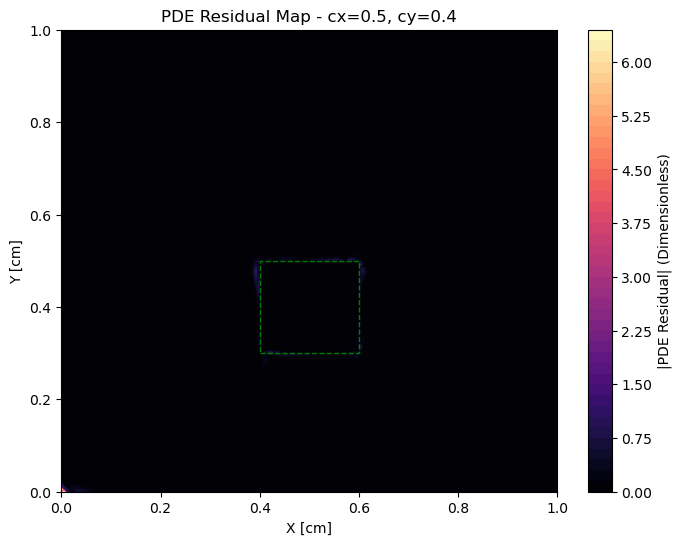

In [3]:
# Position of the scar (CHANGE TO TEST OTHER CONFIGS)
cx_test = 0.5
cy_test = 0.4
scar_edge = 0.2

N_res = 200
X_res, Y_res, X_res_tensor = get_eval_grid(N_res, cx_test, cy_test)
pde_res = compute_residual(model, X_res_tensor, get_M_dynamic)
Residual_Grid = np.abs(pde_res.numpy()).reshape(N_res, N_res)

plot_residual_map(X_res, Y_res, Residual_Grid, cx_test, cy_test,scar_edge)

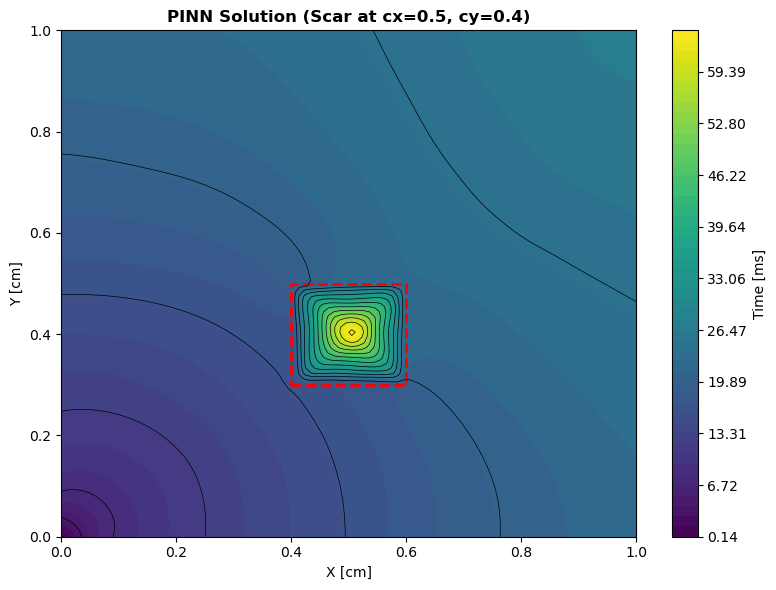

In [4]:
N_fem = N_GRID
X_fem, Y_fem, X_fem_tensor = get_eval_grid(N_fem, cx_test, cy_test)

u_pinn = model(X_fem_tensor).numpy().flatten() * U_SCALE
U_pinn2D = u_pinn.reshape(N_fem, N_fem) * 1000.0

plot_parametric_pinn_solution(
    X_fem=X_fem, 
    Y_fem=Y_fem, 
    U_pinn2D=U_pinn2D, 
    cx_test=cx_test, 
    cy_test=cy_test,
)

In [5]:
test_data_path = os.path.join(base_data_dir, 'test_grid.npz')
data_test = np.load(test_data_path)
coords_test = data_test['coords']   # array (N, 4)
u_fem = data_test['values_clean'].flatten()

u_pinn = predict_in_batches(model, coords_test).flatten() * U_SCALE

test_mse, test_mae = compute_and_print_metrics(u_fem, u_pinn, U_SCALE)


Test MSE (Dimensionless) : 1.401550e-05
Test MAE (Physical)      : 0.1485 ms


101 different scar configurations in the test set.

Configuration (cx, cy)    | Relative L2 Error 
-----------------------------------------------
Scar at cx=0.21, cy=0.34    | 1.70%
Scar at cx=0.21, cy=0.22    | 1.93%
Scar at cx=0.21, cy=0.36    | 1.57%
Scar at cx=0.22, cy=0.38    | 1.36%
Scar at cx=0.22, cy=0.45    | 1.45%
Scar at cx=0.22, cy=0.28    | 1.77%
Scar at cx=0.22, cy=0.73    | 1.53%
Scar at cx=0.25, cy=0.29    | 1.50%
Scar at cx=0.25, cy=0.60    | 1.17%
Scar at cx=0.25, cy=0.66    | 1.38%
Scar at cx=0.26, cy=0.76    | 1.42%
Scar at cx=0.28, cy=0.76    | 1.53%
Scar at cx=0.29, cy=0.64    | 1.24%
Scar at cx=0.29, cy=0.60    | 1.18%
Scar at cx=0.30, cy=0.56    | 1.21%
Scar at cx=0.31, cy=0.21    | 1.47%
Scar at cx=0.31, cy=0.48    | 1.06%
Scar at cx=0.34, cy=0.54    | 1.17%
Scar at cx=0.34, cy=0.72    | 1.29%
Scar at cx=0.35, cy=0.58    | 1.14%
Scar at cx=0.35, cy=0.46    | 1.20%
Scar at cx=0.35, cy=0.73    | 1.30%
Scar at cx=0.36, cy=0.33    | 1.28%
Scar at cx=0.36, cy=0.68 

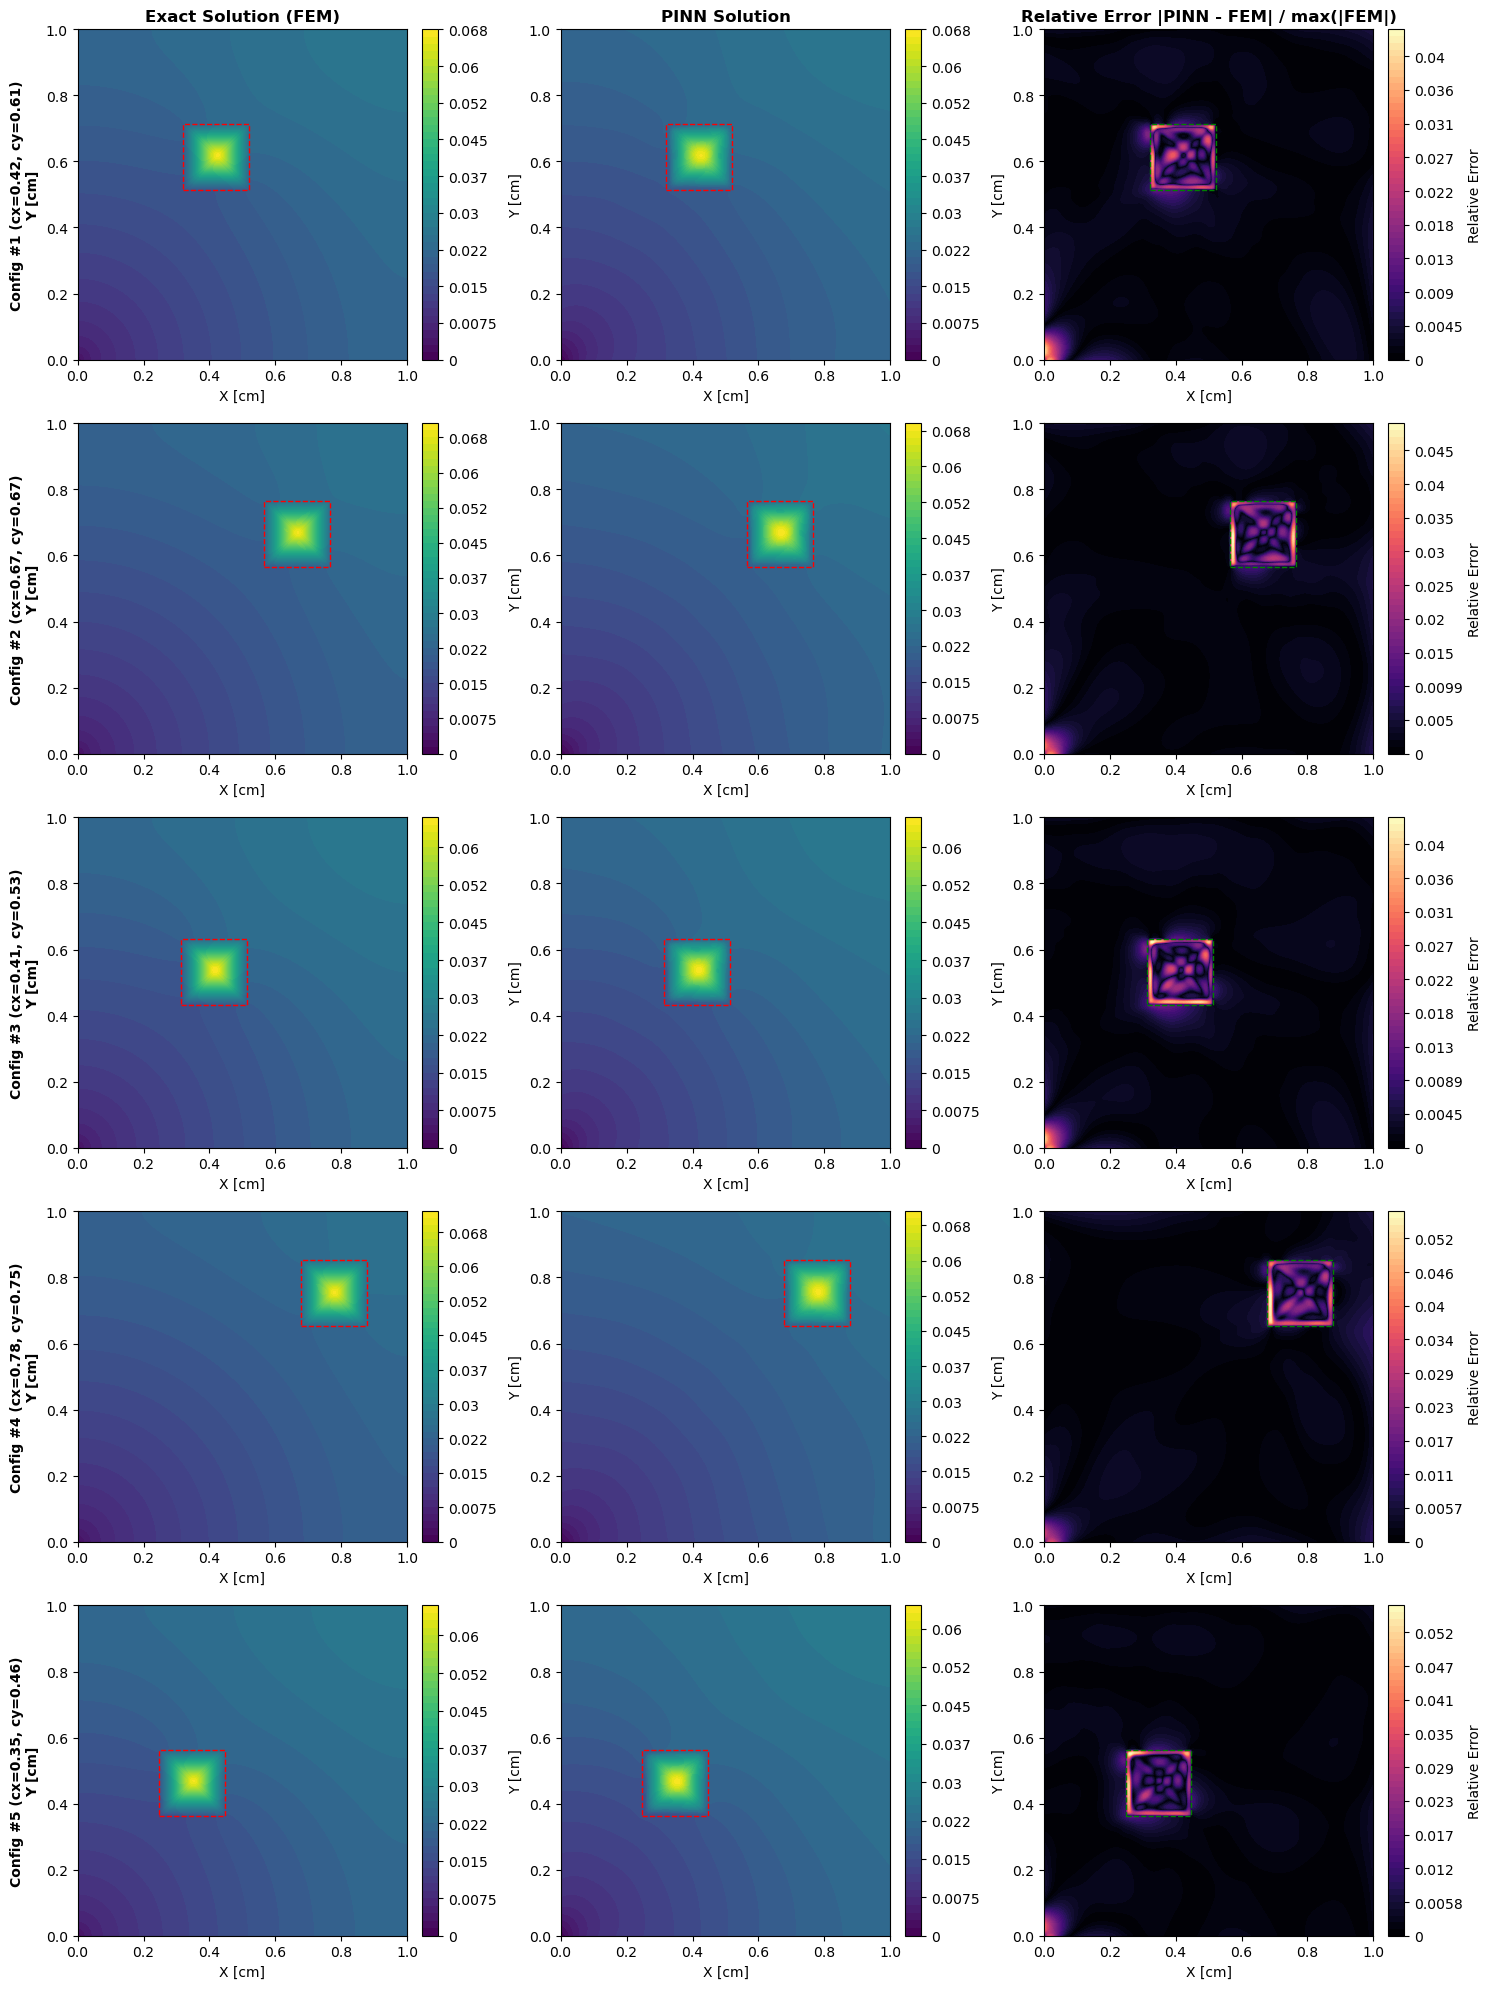

In [6]:
u_fem_all = data_test['values_clean']

evaluate_and_plot_parametric_scars(
    model=model, 
    coords_test=coords_test, 
    u_fem_all=u_fem_all, 
    U_SCALE=U_SCALE, 
    num_to_plot=5,        
    scar_edge=0.2    
)